In [2]:
%load_ext autoreload
%reload_ext autoreload

from helper import fitting, models, plot
from scipy import stats
from scipy.special import erfcinv
from matplotlib import pyplot as plt
from alive_progress import alive_bar
import numpy as np
import pandas as pd
import sys
import os

from biotrace.common import load_dicoms, constants

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [5]:
def get_dir():
    if sys.platform == "win32": # windows
        dir = r"\\svm_uhn\Coolens_Research\Isaac\Experiments\20260806 - Au13-0057 (caprese)\AuNC_run"
    elif sys.platform == "darwin": # mac
        dir = '/Users/isaac/Library/CloudStorage/OneDrive-UHN/Experiments/20260806 - Au130057/AuNC_run'
    else:
        raise ValueError("Unable to get directory.")

    return dir

In [6]:
dir = get_dir()
scans = load_dicoms.DicomSeries(dir)

Skipping CT.1.2.392.200036.9116.2.6.1.44063.1805048915.1786011389.608003.dcm: Missing SliceLocation
Skipping CT.1.2.392.200036.9116.2.6.1.44063.1805048915.1786011389.652303.dcm: Missing SliceLocation
Skipping CT.1.2.392.200036.9116.2.6.1.44063.1805048915.1786011389.702528.dcm: Missing SliceLocation
--------------------
All DICOMs loaded. Run filter_locs() to filter for target SliceLocation(s).


In [7]:
scans.filter_locs(min_loc = 426, dynamic = True)

--------------------
One SliceLocation specified: 426 mm
Closest range found: +426.000 mm to +426.000 mm
Dynamic: 91 DICOM files extracted.


In [8]:
arr_hu = [dicom.pixel_array for dicom in scans.target_dynamic.dicoms]

In [9]:
calib_slope = 20.720
calib_b = 26.358

arr_conc = [(arr - calib_b) / calib_slope for arr in arr_hu]

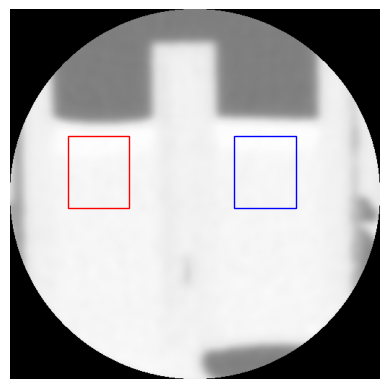

In [10]:
rois = {"roi1": [(175, 80), (100, 85)], # (y_i, x_i), (h, w)
        "roi2": [(175, 310), (100, 85)]}

from matplotlib import patches
fig, ax = plt.subplots()
ax.imshow(arr_hu[0], cmap = plt.cm.grey)

roi1 = patches.Rectangle(
    xy = (80, 175),
    width = 85,
    height = 100,
    color = "red",
    fill = False
)

roi2 = patches.Rectangle(
    xy = (310, 175),
    width = 85,
    height = 100,
    color = "blue",
    fill = False
)

ax.add_patch(roi1)
ax.add_patch(roi2)
ax.set_axis_off()
plt.show()

In [11]:
concs_raw = {}
for roi in rois.keys():
    (y_i, x_i), (h, w) = rois[roi]
    conc_roi = [conc[y_i:y_i + h + 1, x_i:x_i + w + 1] for conc in arr_conc]
    concs_raw[roi] = [np.array(conc) for conc in conc_roi]

concs = {}
for roi in concs_raw.keys():
    concs_roi = concs_raw[roi]
    concs[roi] = np.array([np.nanmean(conc, axis = 1) for conc in concs_roi])

In [ ]:
# concs = {roi: concs[roi] + abs(np.nanmin(concs[roi])) for roi in concs.keys()}

In [12]:
conc1 = concs["roi1"]
conc2 = concs["roi2"]

In [13]:
time = [t + 80 for t in scans.target_dynamic.relative_times]
px_space = scans.target_dynamic.dicoms[0].PixelSpacing[0]
depth = np.arange(0, conc1.shape[1]) * px_space

In [14]:
def plot_prof_2d(concs, time, depth):
    n_concs = len(concs.keys())

    fig, ax = plt.subplots(1, n_concs, figsize = (5 * n_concs, 3))

    for i in range(len(concs.keys())):
        roi = list(concs.keys())[i]
        conc = concs[roi]
        
        profs = range(0, len(time), 10)
        n_profs = len(profs)
        cmap = plt.get_cmap("viridis")
        colors = cmap(np.linspace(0, 1, n_profs))

        j = 0
        for k in profs:
            ax[i].plot(depth, conc[k, :],
                       label = f"{time[k]} s", 
                       color = colors[j])
            j += 1
            ax[i].legend(title = "Timepoint",
                         fontsize = 8,
                         title_fontproperties = {"weight": "bold",
                                                 "size": 8})
            ax[i].set_ylabel("Concentration (mg Au/mL)", size = 9)
            ax[i].set_xlabel("Depth (mm)", size = 9)
            ax[i].grid(alpha = 0.5)

    plt.tight_layout()

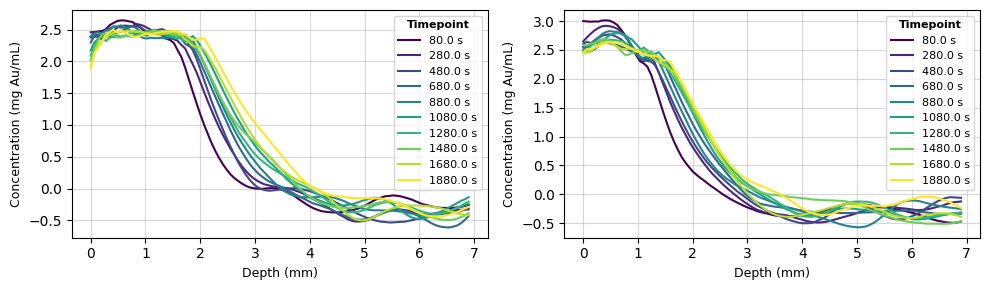

In [15]:
plot_prof_2d(concs, time, depth)

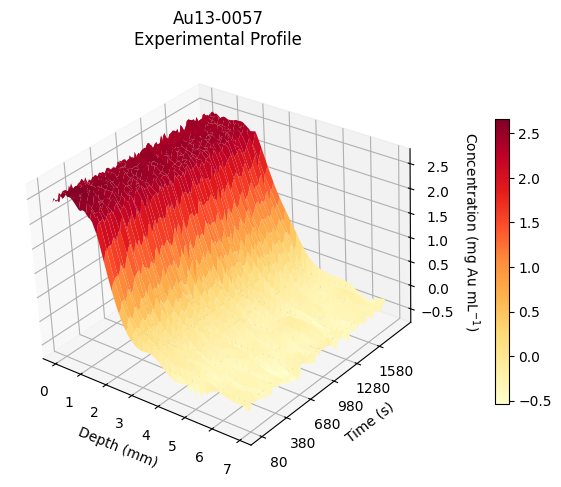

In [16]:
fig, ax = plt.subplots(1, 1, subplot_kw = {"projection": "3d"}, figsize = (6, 6), squeeze = False)
ax = ax.flatten()

depth_mesh, time_mesh = np.meshgrid(depth, time)

plot.plot_prof(fig, ax, 0, x = depth_mesh, y = time_mesh, z = conc1, 
          name = "Au13-0057\nExperimental Profile", 
          elem = "Au")
plt.tight_layout()
plt.show()

In [17]:
def icd_method(c_null, conc, time):
    try:
        t_front = np.sqrt(time)
        x_front = []
        cs_exp = np.nanmean(conc[:, 0])

        for i in range(conc.shape[0]):
            profile = conc[i, :]
            idx = np.where(np.diff(np.sign(profile - c_null)))[0]

            if len(idx) > 0:
                j = idx[0]

                # look at two surrounding rows
                c1, c2 = profile[j], profile[j + 1]
                x1, x2 = depth[j], depth[j + 1]

                # linear interpolation
                x = x1 + (c_null - c1) * (x2 - x1) / (c2 - c1)

                x_front.append(x)
            
            else:
                x_front.append(np.nan)

        n = len(x_front)

        slope, intercept, r_value, p_value, std_err = stats.linregress(t_front, x_front)

        d_front = (slope / (2 * erfcinv(c_null / cs_exp))) ** 2

        df = n - 2
        t_val = stats.t.ppf(0.975, df)
        marg_of_err = t_val * std_err
        slope_lower = slope - marg_of_err
        slope_upper = slope + marg_of_err

        lb = (slope_lower / (2 * erfcinv(c_null / cs_exp))) ** 2
        ub = (slope_upper / (2 * erfcinv(c_null / cs_exp))) ** 2

        # store results
        out = {
            "c_null"        : c_null,
            "t_0.5"         : t_front,
            "iso_front"     : x_front,
            "r2"            : r_value ** 2,
            "slope"         : slope,
            "ci_slope"      : (slope_lower, slope_upper),
            "d"             : d_front,
            "ci_d"          : (lb, ub),
            "intercept"     : intercept
        }
        return out
    
    except Exception as e:
        print(f"Error :{e}")

In [18]:
c_null_list = [0.1, 0.5, 1, 1.5]
icd_results = [icd_method(c_null, conc1, time) for c_null in c_null_list]
for r in icd_results:
    print(f"{r["c_null"]} mg Au/mL: {r["d"]:.2e} [{r["ci_d"][0]:.2e}, {r["ci_d"][1]:.2e}] mm2/s (r2 = {r["r2"]:.3f})")

0.1 mg Au/mL: 4.63e-05 [2.95e-05, 6.68e-05] mm2/s (r2 = 0.523)
0.5 mg Au/mL: 2.37e-04 [2.04e-04, 2.73e-04] mm2/s (r2 = 0.893)
1 mg Au/mL: 4.10e-04 [3.59e-04, 4.65e-04] mm2/s (r2 = 0.914)
1.5 mg Au/mL: 8.17e-04 [7.16e-04, 9.23e-04] mm2/s (r2 = 0.917)


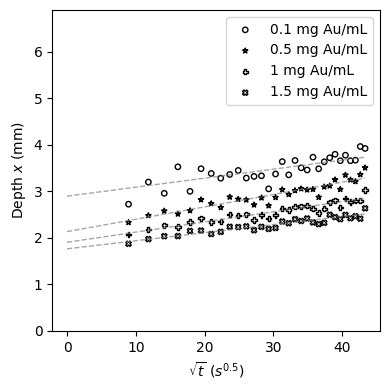

In [40]:
fig, ax = plt.subplots(figsize = (4, 4))
cats = [str(c) + " mg I /mL" for c in c_null_list]
markers = ["o", "*", "P", "X"]

for i, r in enumerate(icd_results):
        t_front = r["t_0.5"]
        x_front = r["iso_front"]
        c_null = r["c_null"]
        intercept = r["intercept"]
        slope = r["slope"]
                                        
        ax.scatter(t_front[::3], x_front[::3], 
                marker = markers[i], 
                edgecolors = "black", 
                facecolors = "none", 
                s  = 15,
                label = f"{c_null} mg Au/mL")
        ax.set_xlabel(f"$\\sqrt{{t}}$ ($s^{{0.5}}$)")
        ax.set_ylabel(f"Depth $x$ (mm)")

        # plot regression line
        x_reg = np.linspace(0, np.nanmax(t_front), len(t_front))
        y_reg = slope * x_reg + intercept
        ax.plot(x_reg, y_reg, 
                linestyle = "--",
                c = "grey",
                alpha = 0.7,
                linewidth = 1)
ax.set_ylim(0, np.nanmax(depth))
plt.legend()  
plt.tight_layout()
plt.show()

In [36]:
# No boundary, so fitting with x0
configs = []
cs_exp = np.nanmean(conc1[:, 0])
d_mode = "global"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp,
                d_init = 1e-6
            )
            configs.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                d_init = 1e-6
            )
            configs.append(cfg)

In [37]:
results_conc1 = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc1[21:,], depth, time[21:], cfg)
        results_conc1.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.1s (1


In [38]:
[print(f"{r.d_global:.2e} mm2/s (r2 = {r.r2_global:.3f})") for r in results_conc1]
[print(f"{r.x0_global:.2e} mm (r2 = {r.r2_global:.3f})") for r in results_conc1]
[print(f"{r.cs_global:.2e} mg Au/mL (r2 = {r.r2_global:.3f})") for r in results_conc1]

1.27e-04 mm2/s (r2 = 0.957)
1.54e-03 mm2/s (r2 = 0.859)
2.53e+00 mm (r2 = 0.957)
1.13e+00 mm (r2 = 0.859)
1.23e+00 mg Au/mL (r2 = 0.957)
2.25e+00 mg Au/mL (r2 = 0.859)


[None, None]

In [23]:
results_conc2 = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc2, depth, time, cfg)
        results_conc2.append(result)
        bar()

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 0.2s (9


In [24]:
[print(f"{r.d_global:.2e} mm2/s (r2 = {r.r2_global:.3f})") for r in results_conc2]
[print(f"{r.x0_global:.2e} mm (r2 = {r.r2_global:.3f})") for r in results_conc2]
[print(f"{r.cs_global:.2e} mg Au/mL (r2 = {r.r2_global:.3f})") for r in results_conc2]

2.08e-04 mm2/s (r2 = 0.947)
1.04e-03 mm2/s (r2 = 0.901)
1.82e+00 mm (r2 = 0.947)
9.94e-01 mm (r2 = 0.901)
1.39e+00 mg Au/mL (r2 = 0.947)
2.25e+00 mg Au/mL (r2 = 0.901)


[None, None]

In [25]:
# No boundary, so fitting with x0
configs = []
cs_exp = np.nanmean(conc1[:, 0])
d_mode = "per-timepoint"

for fit_x0 in [True]:
    for cs_mode in ["global", "fixed"]:
        x0_mode = "global"
        if cs_mode == "fixed":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                cs_fixed = cs_exp,
                d_init = 1e-6
            )
            configs.append(cfg)
        elif cs_mode == "global":
            cfg = fitting.FitConfig(
                model = "semi-infinite",
                fit_x0 = fit_x0,
                x0_bounds = (-np.inf, np.inf),
                d_mode = d_mode,
                cs_mode = cs_mode,
                d_init = 1e-6
            )
            configs.append(cfg)

In [26]:
results_conc1_ptpt = []
with alive_bar(len(configs), title = "Fitting configs", force_tty = True) as bar:
    for cfg in configs:
        result = fitting.fit_diffusion(conc1, depth, time, cfg)
        results_conc1_ptpt.append(result)
        bar()

Fitting configs |                                        | ▁▃▅ 0/2 [0%] in 0s (~

Fitting configs |████████████████████████████████████████| 2/2 [100%] in 6.7s (0


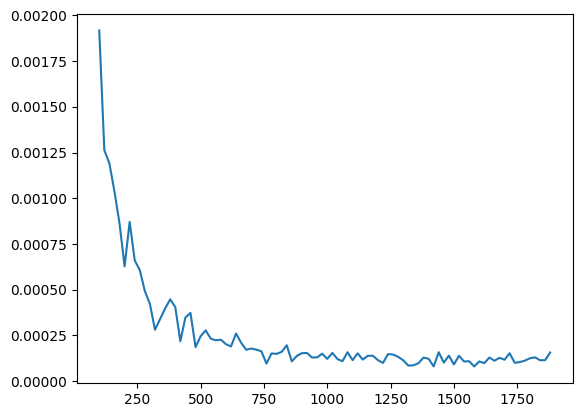

In [27]:
fig, ax = plt.subplots()
ax.plot(time, results_conc1_ptpt[0].d_per_t)